In [ ]:
import time
notebook_start = time.perf_counter()
%pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

Obtaining file:///home/darshan/A6/PCSAFT_cDFT/thermoift
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thermoift (pyproject.toml) ... done
  Created wheel for thermoift: filename=thermoift-0.2.0-0.editable-py3-none-any.whl size=1730 sha256=b36204ca01d7d3384a8806dc9f0c0f07da59cc10807a6e82c30acc8a792269df
  Stored in directory: /tmp/pip-ephem-wheel-cache-_q4bbi4o/wheels/fd/2f/c4/54a2ee5cd16a9bf5b183bbe5c28d1b3ba4926fb0261a13e1e4
Successfully built thermoift
  Attempting uninstall: thermoift
    Found existing installation: thermoift 0.2.0
    Uninstalling thermoift-0.2.0:
      Successfully uninstalled thermoift-0.2.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
from thermoift import FeedsBuilder
from pathlib import Path
from itertools import combinations
import pandas as pd, json
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
from matplotlib.ticker import AutoMinorLocator
import thermoift.PLOT_SETTINGS as ps
import seaborn as sns

OUTPUT_DIR = Path("CSV_feeds")
OUTPUT_DIR.mkdir(exist_ok=True)

COMPONENTS  = ["CO2", "H2", "Ar", "N2", "CH4", "O2", "CO", "H2S"]
CO2_LEVELS  = (0.95, 0.96, 0.97, 0.98, 0.99)
SEED        = 550055

# Dirichlet alpha: based on typical industrial impurity bounds
# Higher alpha = component tends to take larger share of impurity
# Lower alpha = component tends toward trace amounts
ALPHA = {
    "N2":  5.0,   # up to 4% in industrial streams
    "CH4": 5.0,   # up to 5% (dominant impurity)
    "H2":  5.0,   # up to 4%
    "Ar":  5.0,   # moderate
    "O2":  0.1,   # trace (10 ppm)
    "CO":  0.1,   # trace (35 ppm)
    "H2S": 0.1,   # trace (100 ppm)
}

builder = FeedsBuilder(rng_type="PCG64", seed=SEED)

### 1. Random feeds (Dirichlet sampling)

In [3]:
df_random = builder.generate_random_feeds(
    components=COMPONENTS,
    mixture_sizes=(2, 3),
    co2_levels=CO2_LEVELS,
    n_random_samples=200, 
    alpha=ALPHA,  # Controls the degree of bias towards higher CO2 levels (0 = no bias, 1 = strong bias)
)

print(f"Random feeds: {len(df_random)}")
df_random.head()

Random feeds: 28000


,CO2,H2,Ar,N2,CH4,O2,CO,H2S,mixture_size,active_components,feed_source,template_name
0,0.95,0.05,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",Random (Dirichlet),dirichlet
1,0.95,0.05,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",Random (Dirichlet),dirichlet
2,0.95,0.05,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",Random (Dirichlet),dirichlet
3,0.95,0.05,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",Random (Dirichlet),dirichlet
4,0.95,0.05,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",Random (Dirichlet),dirichlet


### 2. Systematic feeds (grid at fixed step)

In [4]:
df_systematic = builder.generate_systematic_feeds(
    components=COMPONENTS,
    mixture_sizes=(2, 3),
    co2_levels=CO2_LEVELS,
    step=0.01, min_fraction=0.005)

print(f"Systematic feeds: {len(df_systematic)}")
df_systematic.head()

Systematic feeds: 245


,CO2,H2,Ar,N2,CH4,O2,CO,H2S,mixture_size,active_components,feed_source,template_name
0,0.95,0.05,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",Systematic,systematic_grid
1,0.96,0.04,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",Systematic,systematic_grid
2,0.97,0.03,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",Systematic,systematic_grid
3,0.98,0.02,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",Systematic,systematic_grid
4,0.99,0.01,0.0,0.0,0.0,0.0,0.0,0.0,2,"CO2,H2",Systematic,systematic_grid


### 3. Industrial feeds (bounds + ranges templates)

In [5]:
builder.load_industrial_templates("IndustrialFeeds.json")

df_ind_bounds = builder.industrial_feeds_from_bounds(
    components=COMPONENTS,
    co2_levels=CO2_LEVELS)

df_ind_ranges = builder.industrial_feeds_from_ranges(
    components=COMPONENTS)

df_industrial = pd.concat([df_ind_bounds, df_ind_ranges], ignore_index=True)
print(f"Industrial feeds: {len(df_industrial)}  (bounds={len(df_ind_bounds)}, ranges={len(df_ind_ranges)})")
df_industrial.head()

Industrial feeds: 320  (bounds=180, ranges=140)


,CO2,H2,Ar,N2,CH4,O2,CO,H2S,feed_source,template_name,mixture_size,active_components
0,0.95,0.002149,0.004174,0.003678,0.039930,0.000009,0.000034,0.000025,industrial_bound,netl_limits,8,"CO2,O2,H2S,N2,CO,H2,Ar,CH4"
1,0.95,0.004809,0.009075,0.008293,0.027702,0.000003,0.000022,0.000096,industrial_bound,netl_limits,8,"CO2,O2,H2S,N2,CO,H2,Ar,CH4"
2,0.95,0.016024,0.006432,0.011585,0.015875,0.000004,0.000025,0.000056,industrial_bound,netl_limits,8,"CO2,O2,H2S,N2,CO,H2,Ar,CH4"
3,0.95,0.003361,0.008564,0.010973,0.027076,0.000003,0.000012,0.000011,industrial_bound,netl_limits,8,"CO2,O2,H2S,N2,CO,H2,Ar,CH4"
4,0.95,0.012451,0.002706,0.016591,0.018218,0.000008,0.000022,0.000004,industrial_bound,netl_limits,8,"CO2,O2,H2S,N2,CO,H2,Ar,CH4"


### 4. Combined feed (70% random / 20% systematic / 10% industrial)

In [6]:
df_all = builder.combine_feeds_random_systematic_industrial(
    components=COMPONENTS,
    n_total_target=100,
    co2_levels=CO2_LEVELS,
    frac_random=0.70,
    frac_systematic=0.20,
    frac_industrial=0.10,
)

print(f"Total feeds: {len(df_all)}")
print()
print(df_all["feed_source"].value_counts())
print()
df_all.head(10)

Total feeds: 100

feed_source
Random (Dirichlet)    70
Systematic            20
industrial_bound       9
industrial_range       1
Name: count, dtype: int64



,feed_source,template_name,mixture_size,active_components,CO2,H2,Ar,N2,CH4,O2,CO,H2S
0,Random (Dirichlet),dirichlet,5,"CO2,H2,Ar,CO,H2S",0.99,0.002825,0.003180,0.000000,0.000000,0.000000,0.001426,0.002569
1,Random (Dirichlet),dirichlet,5,"CO2,H2,Ar,N2,CO",0.95,0.002354,0.004507,0.036806,0.000000,0.000000,0.006332,0.000000
2,Random (Dirichlet),dirichlet,3,"CO2,Ar,H2S",0.97,0.000000,0.028501,0.000000,0.000000,0.000000,0.000000,0.001499
3,Random (Dirichlet),dirichlet,3,"CO2,O2,H2S",0.97,0.000000,0.000000,0.000000,0.000000,0.012892,0.000000,0.017108
4,Random (Dirichlet),dirichlet,2,"CO2,CH4",0.95,0.000000,0.000000,0.000000,0.050000,0.000000,0.000000,0.000000
5,Random (Dirichlet),dirichlet,4,"CO2,H2,Ar,CO",0.96,0.010142,0.015014,0.000000,0.000000,0.000000,0.014844,0.000000
6,Random (Dirichlet),dirichlet,3,"CO2,CH4,CO",0.95,0.000000,0.000000,0.000000,0.024680,0.000000,0.025320,0.000000
7,Random (Dirichlet),dirichlet,5,"CO2,H2,CH4,O2,H2S",0.96,0.004354,0.000000,0.000000,0.019941,0.002630,0.000000,0.013075
8,Random (Dirichlet),dirichlet,5,"CO2,H2,N2,O2,H2S",0.98,0.003998,0.000000,0.009112,0.000000,0.000162,0.000000,0.006728
9,Random (Dirichlet),dirichlet,4,"CO2,H2,N2,H2S",0.99,0.003787,0.000000,0.003790,0.000000,0.000000,0.000000,0.002422


### 5. Save all feeds

In [7]:
# Save individual feeds
df_random.to_csv(OUTPUT_DIR / "Random_compositions.csv", index=False)
df_systematic.to_csv(OUTPUT_DIR / "Systematic_compositions.csv", index=False)
df_industrial.to_csv(OUTPUT_DIR / "Industrial_compositions.csv", index=False)

# Save combined feed
df_all.to_csv(OUTPUT_DIR / "Combined_compositions.csv", index=False)

print(f"Saved to {OUTPUT_DIR}/:")
print(f"  Random_compositions.csv       : {len(df_random)} rows")
print(f"  Systematic_compositions.csv   : {len(df_systematic)} rows")
print(f"  Industrial_compositions.csv   : {len(df_industrial)} rows")
print(f"  Combined_compositions.csv     : {len(df_all)} rows")

Saved to CSV_feeds/:
  Random_compositions.csv       : 28000 rows
  Systematic_compositions.csv   : 245 rows
  Industrial_compositions.csv   : 320 rows
  Combined_compositions.csv     : 100 rows


### 6. Generate default KIJ pairs config

In [8]:
# Generate default KIJ_pairs.json (all pairs by default set to "zero")

COMPONENTS = ["CO2", "H2", "Ar", "N2", "CH4", "O2", "CO", "H2S"]
pairs = [f"{a}-{b}" for a, b in combinations(COMPONENTS, 2)]
kij_pairs = {pair: "zero" for pair in pairs}

kij_file = OUTPUT_DIR / "KIJ_pairs.json"
with open(kij_file, "w") as f:
    json.dump(kij_pairs, f, indent=2)

print(f"Generated {kij_file} with {len(kij_pairs)} pairs (all set to 'zero')")
print("\nEdit this file to override specific pairs:")
print("  Options: 'zero', 'constant', 'linear'")

Generated CSV_feeds/KIJ_pairs.json with 28 pairs (all set to 'zero')

Edit this file to override specific pairs:
  Options: 'zero', 'constant', 'linear'


In [9]:
INPUT_FILE = Path("CSV_feeds/Combined_compositions.csv")
df = pd.read_csv(INPUT_FILE)
df["feed_source_plot"] = df["feed_source"].replace({
    "industrial_range": "Industrial",
    "industrial_bound": "Industrial"
})

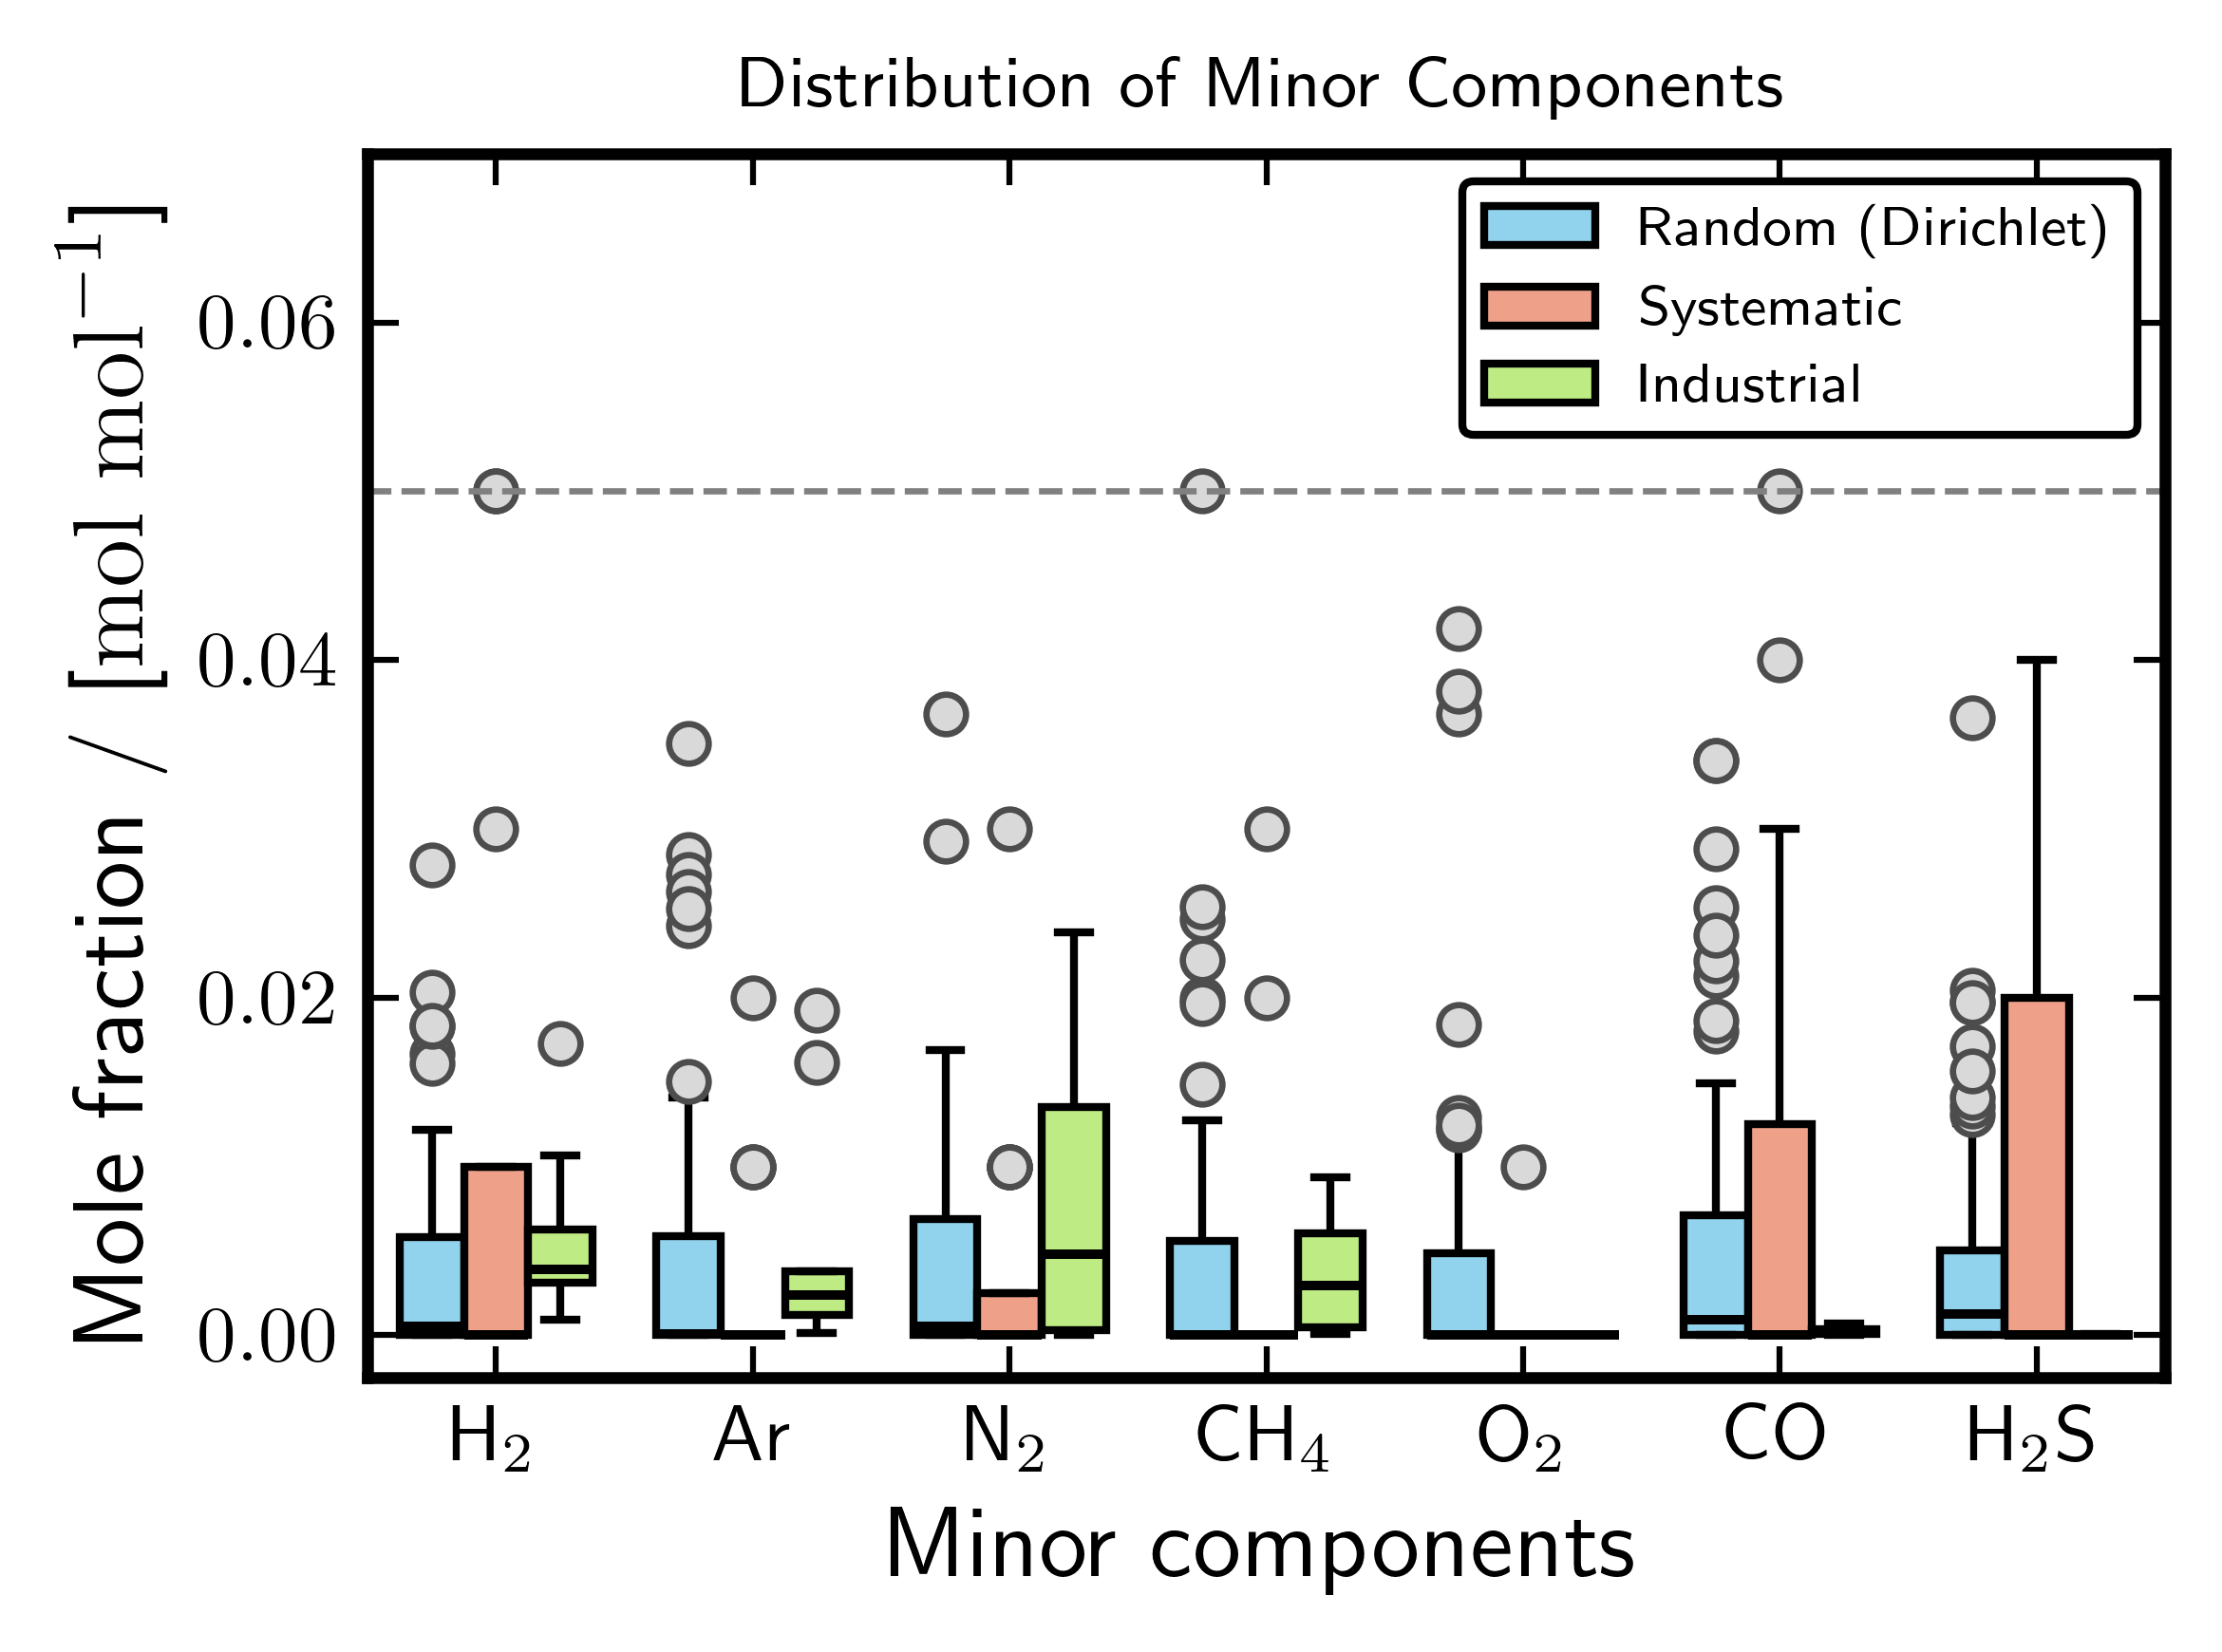

In [10]:
palette = ["#81dafd", "#ff9778", "#c0fc72"]

minor_cols = ['H2', 'Ar', 'N2', 'CH4', 'O2', 'CO', 'H2S']

plot_df = df[['feed_source_plot'] + minor_cols].copy()
plot_df = plot_df.melt(
    id_vars='feed_source_plot',
    value_vars=minor_cols,
    var_name='Component',
    value_name='Mole fraction'
)

rename_map = {
    "H2":  r"H$_2$",
    "Ar":  r"Ar",
    "N2":  r"N$_2$",
    "CH4": r"CH$_4$",
    "O2":  r"O$_2$",
    "CO":  r"CO",
    "H2S": r"H$_2$S"
}
plot_df["Component"] = plot_df["Component"].map(rename_map)

fig, ax = ps.plot_init()

sns.boxplot(
    data=plot_df,
    x="Component",
    y="Mole fraction",
    hue="feed_source_plot",
    ax=ax,
    palette=palette,
    linewidth=1.0,
    fliersize=4,
    width=0.75,
    boxprops=dict(edgecolor='black', linewidth=1.0),
    whiskerprops=dict(color='black', linewidth=1.0),
    capprops=dict(color='black', linewidth=1.0),
    medianprops=dict(color='black', linewidth=1.2),
    flierprops=dict(
        marker='o',
        markerfacecolor='#d9d9d9',
        markeredgecolor='#4d4d4d',
        markersize=5,
        linestyle='none',
        markeredgewidth=0.8
    )
)

ax.axhline(0.05, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel("Minor components", fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Mole fraction / [$\mathrm{mol}\ \mathrm{mol}^{-1}$]", fontsize=ps.label_fontsize * 0.9)
ax.set_title("Distribution of Minor Components",
             fontsize=ps.title_fontsize * 0.75,
             fontweight="bold")

ps.apply_axis_style(ax)
ax.legend(fontsize=ps.label_fontsize * 0.5, loc="upper right",
          edgecolor="black", facecolor="white", framealpha=1.0)
ax.set_ylim(top=0.07)
plt.tight_layout()
ps.save_plot(fig, "boxplot_minor_components")
plt.show()

In [11]:
elapsed = time.perf_counter() - notebook_start
print(f"\nNotebook runtime: {elapsed:.1f}s")


Notebook runtime: 8.7s
